In [1]:
import os
os.environ["WORLD_SIZE"] = "1"
os.environ["RANK"] = "0"
os.environ["LOCAL_RANK"] = "0"
os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "12355"

# Adding a New Model Wrapper to the Benchmarking Workflow

The PhysicsNeMo benchmarking workflow uses **model wrappers** to decouple models from datasets and metrics. Each wrapper implements the `CFDModel` interface — four methods that handle loading weights, preparing inputs, running inference, and decoding outputs into the canonical schema.

In this notebook we walk through the process by building a toy **SineCosine** model wrapper. The model applies simple trigonometric transformations to mesh coordinates to produce (obviously wrong) pressure and wall shear stress predictions. Despite being trivially simple, this exercises every part of the wrapper contract and runs end-to-end through the benchmarking engine against real DrivAerML data.

## The `CFDModel` Interface

Every model wrapper subclasses `CFDModel` (defined in `physicsnemo.cfd.evaluation.models.model_registry`) and provides:

| Member | Role |
|--------|------|
| `INFERENCE_DOMAIN` (class var) | `"surface"` or `"volume"` — which mesh manifold the model operates on |
| `OUTPUT_LOCATION` (class var) | `"point"` or `"cell"` — where predictions live on the mesh |
| `output_location` (property) | Instance-level access to output location |
| `load(checkpoint_path, stats_path, device, **kwargs)` | Load weights and normalization stats; return `self` |
| `prepare_inputs(case: CanonicalCase)` | Convert canonical case into model-specific tensors |
| `predict(model_input)` | Run forward pass; return raw model output |
| `decode_outputs(raw_output, case)` | Denormalize and map to canonical predictions dict (`pressure`, `shear_stress`) |

The engine calls these in sequence: `load` once, then `prepare_inputs → predict → decode_outputs` per case. The wrapper never needs to know which dataset adapter produced the `CanonicalCase`.

## Writing the SineCosine Model Wrapper

Our dummy model will:

1. **Load** a set of scalar parameters (frequencies, scale, bias) from a `.pt` checkpoint
2. **Prepare inputs** by extracting mesh cell-center coordinates as a `(N, 3)` tensor
3. **Predict** pressure and wall shear stress using products of sin/cos at two frequency scales
4. **Decode** by moving tensors to numpy and assembling the canonical prediction dict with `build_predictions_dict(...)`

This is intentionally minimal — a real wrapper would load a neural network, handle batching, and apply learned normalization.

In [2]:
import numpy as np
import torch
import pyvista as pv

from physicsnemo.cfd.evaluation.models.model_registry import (
    CFDModel, register_model, OutputLocation,
)
from physicsnemo.cfd.evaluation.datasets.schema import (
    CanonicalCase, InferenceDomain, build_predictions_dict,
)
from physicsnemo.cfd.evaluation.inference.progress import log_inference

from typing import Any, ClassVar


class SineCosineWrapper(CFDModel):
    """Toy model wrapper: trigonometric transforms on mesh coordinates.

    Loads scalar parameters from a .pt checkpoint and applies sin/cos
    to cell-center coordinates to produce dummy pressure and WSS fields.
    Useful for testing the wrapper contract and benchmarking pipeline.
    """

    INFERENCE_DOMAIN: ClassVar[InferenceDomain] = "surface"
    OUTPUT_LOCATION: ClassVar[OutputLocation] = "cell"

    def __init__(self) -> None:
        self._weights: dict[str, torch.Tensor] | None = None
        self._device: str = "cpu"

    @property
    def output_location(self) -> OutputLocation:
        return self.OUTPUT_LOCATION

    def load(
        self,
        checkpoint_path: str,
        stats_path: str,
        device: str,
        **kwargs: Any,
    ) -> "SineCosineWrapper":
        self._device = device
        self._weights = torch.load(
            checkpoint_path, map_location=device, weights_only=True,
        )
        log_inference(
            "sine_cosine",
            f"Loaded {len(self._weights)} parameters from {checkpoint_path}",
        )
        return self

    def prepare_inputs(self, case: CanonicalCase) -> torch.Tensor:
        mesh = pv.read(case.mesh_path)
        if not isinstance(mesh, pv.PolyData):
            mesh = mesh.extract_surface()
        coords = np.array(mesh.cell_centers().points, dtype=np.float32)
        log_inference(
            "sine_cosine",
            f"Prepared {coords.shape[0]} cell-center coordinates for case {case.case_id}",
        )
        return torch.tensor(coords, device=self._device)

    def predict(self, model_input: torch.Tensor) -> dict[str, torch.Tensor]:
        w = self._weights
        x, y, z = model_input[:, 0], model_input[:, 1], model_input[:, 2]

        pressure = (
            w["p_scale"]
            * torch.sin(w["p_freq_lo"] * (x + y + z))
            * torch.cos(w["p_freq_hi"] * x)
            * torch.sin(w["p_freq_hi"] * z)
            + w["p_bias"]
        )

        wss_x = (
            w["wss_scale"]
            * torch.sin(w["wss_freq_lo"] * x)
            * torch.cos(w["wss_freq_hi"] * (y - z))
        )
        wss_y = (
            w["wss_scale"]
            * torch.cos(w["wss_freq_lo"] * y)
            * torch.sin(w["wss_freq_hi"] * (x + z))
        )
        wss_z = (
            w["wss_scale"]
            * torch.sin(w["wss_freq_lo"] * (x + y))
            * torch.cos(w["wss_freq_hi"] * z)
        )
        wss = torch.stack([wss_x, wss_y, wss_z], dim=1)

        log_inference("sine_cosine", "Forward pass complete (sin/cos transforms).")
        return {"pressure": pressure, "shear_stress": wss}

    def decode_outputs(
        self,
        raw_output: dict[str, torch.Tensor],
        case: CanonicalCase,
        model_input: torch.Tensor | None = None,
    ) -> dict[str, np.ndarray]:
        log_inference("sine_cosine", "Decoding outputs to numpy.")
        return build_predictions_dict(
            pressure=raw_output["pressure"].cpu().numpy(),
            shear_stress=raw_output["shear_stress"].cpu().numpy(),
        )


register_model("sine_cosine", SineCosineWrapper)
print("Registered 'sine_cosine' model wrapper.")

/localhome/local-ktangsali/development_workspace/physicsnemo-cfd-api-docs/physicsnemo-cfd/physicsnemo/cfd/evaluation/models/wrappers/geotransolver/wrapper.py:66: ExperimentalFeatureWarning: You are importing from 'physicsnemo.experimental'. The APIs in this namespace are experimental, under active development, and may change without notice. Expect possible back-compatibility breaking changes and only partial test coverage.
  from physicsnemo.experimental.models.geotransolver import GeoTransolver


Registered 'sine_cosine' model wrapper.


## Creating Dummy Weights

Real model wrappers load trained neural network checkpoints. For our toy model, we create a simple `.pt` file containing the scalar parameters that control the trigonometric transforms. We also create a minimal `global_stats.json` — the `load` method receives `stats_path` but our toy model ignores it. Real wrappers use it for denormalization.

In [3]:
import tempfile
import json

weights = {
    "p_scale": torch.tensor(200.0),
    "p_freq_lo": torch.tensor(0.8),
    "p_freq_hi": torch.tensor(3.0),
    "p_bias": torch.tensor(-50.0),
    "wss_scale": torch.tensor(8.0),
    "wss_freq_lo": torch.tensor(1.2),
    "wss_freq_hi": torch.tensor(4.0),
}

CKPT_DIR = tempfile.mkdtemp(prefix="sine_cosine_model_")
CKPT_PATH = os.path.join(CKPT_DIR, "checkpoint.pt")
STATS_PATH = os.path.join(CKPT_DIR, "global_stats.json")

torch.save(weights, CKPT_PATH)

dummy_stats = {
    "mean": {"pressure": [0.0], "shear_stress": [0.0, 0.0, 0.0]},
    "std_dev": {"pressure": [1.0], "shear_stress": [1.0, 1.0, 1.0]},
}
with open(STATS_PATH, "w") as f:
    json.dump(dummy_stats, f, indent=2)

print(f"Checkpoint: {CKPT_PATH}")
print(f"Stats:      {STATS_PATH}")
print(f"Parameters: {list(weights.keys())}")

Checkpoint: /tmp/sine_cosine_model_jg0yo_mw/checkpoint.pt
Stats:      /tmp/sine_cosine_model_jg0yo_mw/global_stats.json
Parameters: ['p_scale', 'p_freq_lo', 'p_freq_hi', 'p_bias', 'wss_scale', 'wss_freq_lo', 'wss_freq_hi']


## Loading a DrivAerML Case

Since model wrappers consume `CanonicalCase` objects, we can use any registered dataset adapter. Below we use the built-in DrivAerML adapter to load a real case — the same data that production models like GeoTransolver and Transolver are evaluated against.

In [4]:
import urllib.request
from pathlib import Path
from physicsnemo.cfd.evaluation.datasets.adapters.drivaerml import DrivAerMLAdapter

# Download a small DrivAerML subset from Hugging Face into the canonical
# ``run_<id>/boundary_<id>.vtp`` + ``drivaer_<id>.stl`` layout (skips existing files).
DRIVAERML_ROOT = "./drivaerml_data"
INFERENCE_CASES = ["run_1", "run_11"]

HF_ROOT = "https://huggingface.co/datasets/neashton/drivaerml/resolve/main"
for case_id in INFERENCE_CASES:
    run_idx = case_id.split("_", 1)[1]
    run_dir = Path(DRIVAERML_ROOT) / case_id
    run_dir.mkdir(parents=True, exist_ok=True)
    for fname in (f"boundary_{run_idx}.vtp", f"drivaer_{run_idx}.stl"):
        dst = run_dir / fname
        if dst.exists():
            continue
        print(f"Downloading {case_id}/{fname}...")
        urllib.request.urlretrieve(f"{HF_ROOT}/{case_id}/{fname}", str(dst))

adapter = DrivAerMLAdapter(root=DRIVAERML_ROOT, inference_domain="surface")
all_cases = adapter.list_cases()
print(f"DrivAerML subset has {len(all_cases)} cases: {all_cases}")

case = adapter.load_case(INFERENCE_CASES[0])
print(f"\nCase: {case.case_id}")
print(f"Mesh path: {case.mesh_path}")
print(f"Mesh type: {case.mesh_type}")
print(f"Inference domain: {case.inference_domain}")
if case.ground_truth:
    print(f"GT keys: {list(case.ground_truth.keys())}")
    for k, v in case.ground_truth.items():
        print(f"  {k}: shape={v.shape}")


DrivAerML subset has 2 cases: ['run_1', 'run_11']
[dataset:drivaerml] load_case('run_1'): branch='surface', root=drivaerml_data


[dataset:drivaerml] Reading surface mesh from drivaerml_data/run_1/boundary_1.vtp



Case: run_1
Mesh path: drivaerml_data/run_1/boundary_1.vtp
Mesh type: cell
Inference domain: surface
GT keys: ['pressure', 'shear_stress']
  pressure: shape=(8828095,)
  shear_stress: shape=(8828095, 3)


## Running Inference Step by Step

The engine calls four methods in sequence. Let's trace each step to see exactly what happens.

In [5]:
import time

wrapper = SineCosineWrapper()
wrapper.load(checkpoint_path=CKPT_PATH, stats_path=STATS_PATH, device="cuda:0")

case = adapter.load_case(INFERENCE_CASES[0])
print(f"--- Case {case.case_id} ---")

start = time.time()

# Step 1: prepare_inputs
model_input = wrapper.prepare_inputs(case)
print(f"\nprepare_inputs -> tensor shape: {model_input.shape}, device: {model_input.device}")
print(f"  coordinate ranges: x=[{model_input[:,0].min():.2f}, {model_input[:,0].max():.2f}], "
      f"y=[{model_input[:,1].min():.2f}, {model_input[:,1].max():.2f}], "
      f"z=[{model_input[:,2].min():.2f}, {model_input[:,2].max():.2f}]")

# Step 2: predict
raw_output = wrapper.predict(model_input)
print(f"\npredict -> keys: {list(raw_output.keys())}")
for k, v in raw_output.items():
    print(f"  {k}: shape={v.shape}, range=[{v.min():.4f}, {v.max():.4f}]")

# Step 3: decode_outputs
predictions = wrapper.decode_outputs(raw_output, case)
elapsed = time.time() - start
print(f"\ndecode_outputs -> keys: {list(predictions.keys())}")
for k, v in predictions.items():
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

print(f"\nTotal inference time: {elapsed:.3f}s")

[inference:sine_cosine] Loaded 7 parameters from /tmp/sine_cosine_model_jg0yo_mw/checkpoint.pt


[dataset:drivaerml] load_case('run_1'): branch='surface', root=drivaerml_data


[dataset:drivaerml] Reading surface mesh from drivaerml_data/run_1/boundary_1.vtp


--- Case run_1 ---


[inference:sine_cosine] Prepared 8828095 cell-center coordinates for case run_1



prepare_inputs -> tensor shape: torch.Size([8828095, 3]), device: cuda:0
  coordinate ranges: x=[-0.77, 3.94], y=[-1.01, 1.01], z=[-0.32, 1.20]
[inference:sine_cosine] Forward pass complete (sin/cos transforms).



predict -> keys: ['pressure', 'shear_stress']
  pressure: shape=torch.Size([8828095]), range=[-238.0141, 147.8146]
  shear_stress: shape=torch.Size([8828095, 3]), range=[-8.0000, 8.0000]
[inference:sine_cosine] Decoding outputs to numpy.



decode_outputs -> keys: ['pressure', 'shear_stress']
  pressure: shape=(8828095,), dtype=float32
  shear_stress: shape=(8828095, 3), dtype=float32

Total inference time: 8.469s


## Saving a Comparison Mesh

Let's overlay the dummy predictions onto the mesh alongside the ground truth. The sine/cosine model will obviously not match the real CFD solution, but this confirms the pipeline is working end-to-end.

In [6]:
import pyvista as pv
vis_mesh = pv.read(case.mesh_path)
vis_mesh.cell_data["pMeanTrimPred_SineCosine"] = predictions["pressure"]
vis_mesh.cell_data["wallShearStressMeanTrimPred_SineCosine"] = predictions["shear_stress"]

os.makedirs("sine_cosine_benchmark_results", exist_ok=True)
vis_mesh.save("sine_cosine_benchmark_results/predictions_comparison.vtp")

print(f"Mesh arrays: {list(vis_mesh.cell_data.keys())}")
print(f"Saved to sine_cosine_benchmark_results/predictions_comparison.vtp")

Mesh arrays: ['CpMeanTrim', 'pMeanTrim', 'pPrime2MeanTrim', 'wallShearStressMeanTrim', 'pMeanTrimPred_SineCosine', 'wallShearStressMeanTrimPred_SineCosine']
Saved to sine_cosine_benchmark_results/predictions_comparison.vtp


## Visualizing the Predicted Fields

Since this is a toy model producing trigonometric patterns, comparing against the CFD ground truth is not very informative. Instead, let's visualize just the predicted fields so we can see the sinusoidal patterns mapped onto the car geometry. We use `plot_fields` which renders each field in its own panel without any GT comparison.

2026-05-09 23:08:08.276 (  65.725s) [    771FC217C080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Saved sine_cosine_benchmark_results/sinecosine_predicted_fields.png


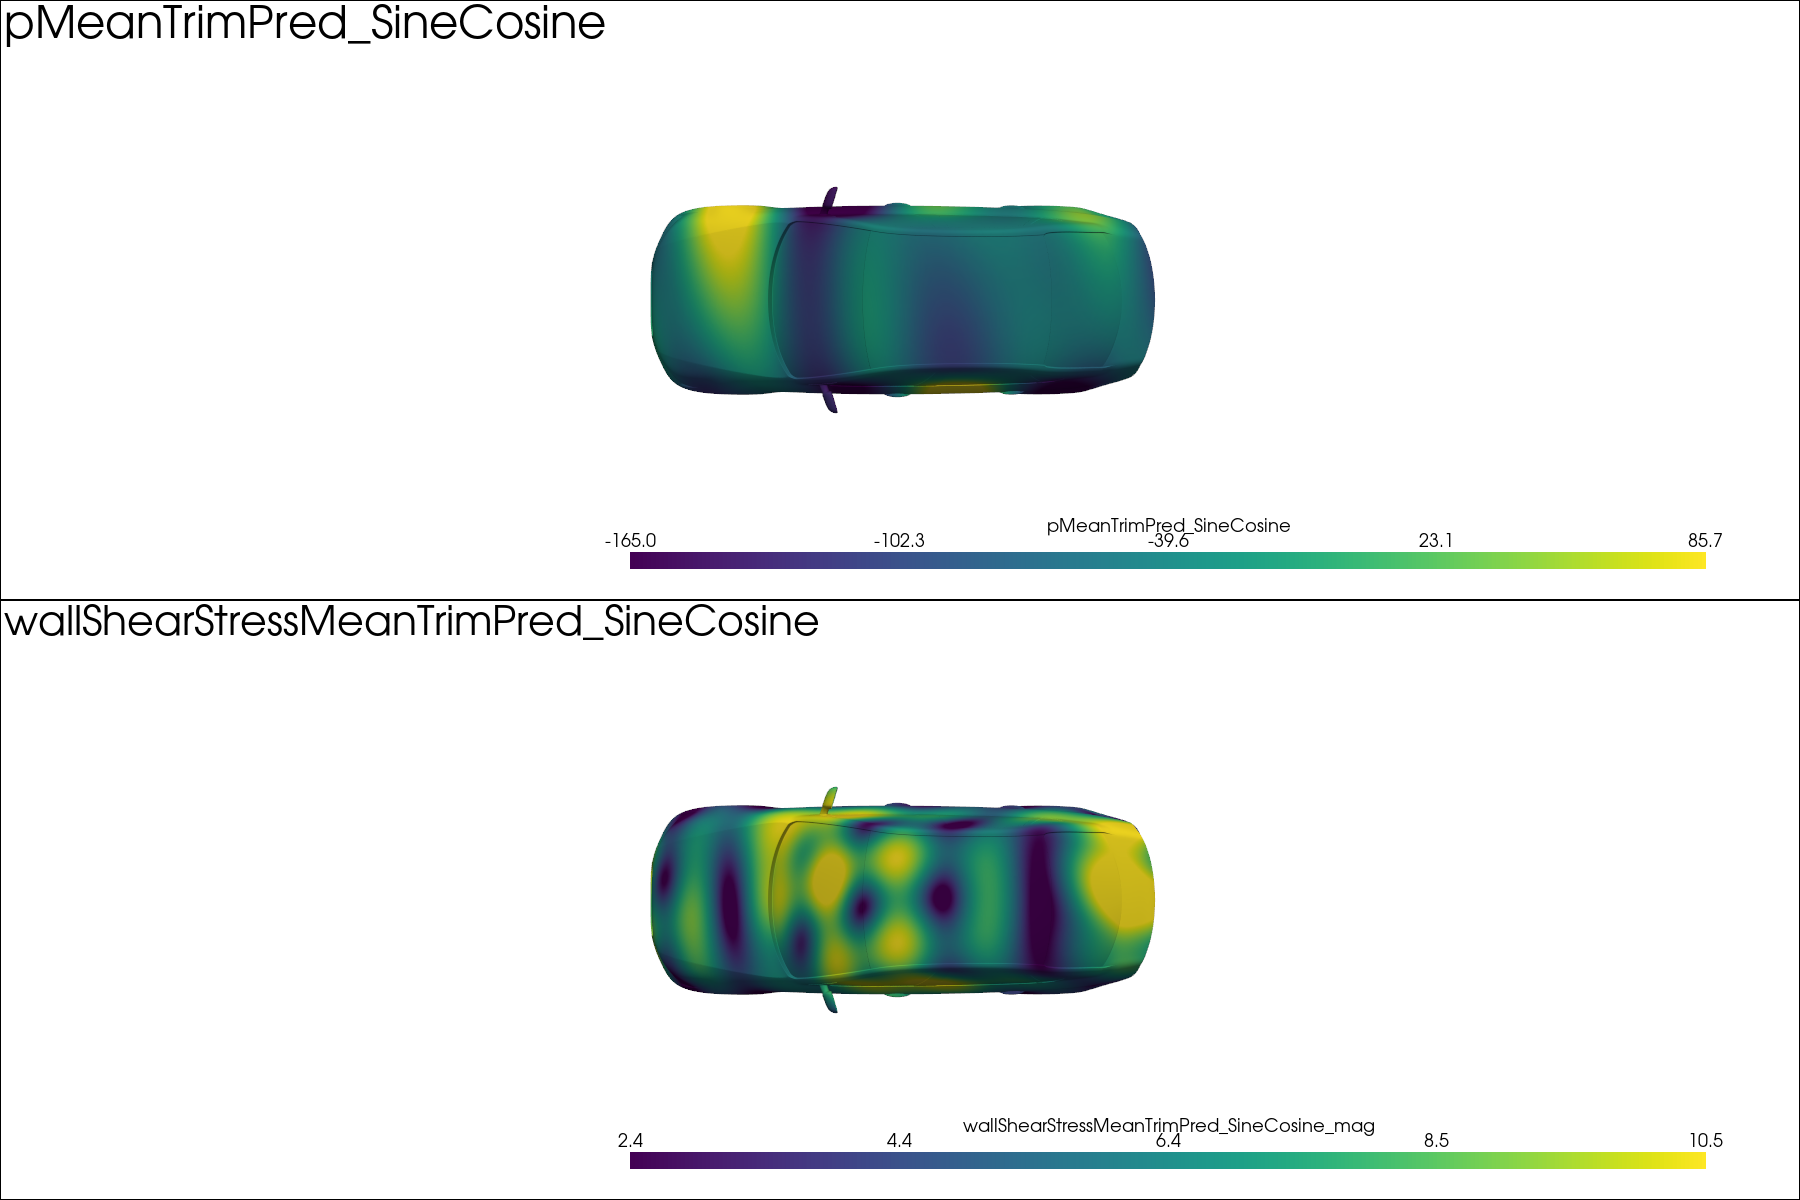

In [7]:
import pyvista as pv
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_fields
from IPython.display import Image, display

_xvfb = getattr(pv, "start_xvfb", None)
if _xvfb is not None:
    _xvfb()
else:
    pv.OFF_SCREEN = True

plotter = plot_fields(
    vis_mesh,
    fields=["pMeanTrimPred_SineCosine", "wallShearStressMeanTrimPred_SineCosine"],
    view="xy",
    dtype="cell",
    window_size=[1800, 1200],
)
fields_path = "sine_cosine_benchmark_results/sinecosine_predicted_fields.png"
plotter.screenshot(fields_path)
plotter.close()
print(f"Saved {fields_path}")

display(Image(filename=fields_path))

## Running the Full Benchmark

With the wrapper registered as `"sine_cosine"`, we can use the full benchmarking engine. The configuration below runs it in matrix mode against DrivAerML, computing L2 errors, area-weighted L2, and drag/lift metrics — the same pipeline used for production models.

In [8]:
from physicsnemo.cfd.evaluation.config import Config
from physicsnemo.cfd.evaluation.benchmarks.engine import run_benchmark

config = Config.from_dict({
    "run": {
        "device": "cuda:0",
        "output_dir": "sine_cosine_benchmark_results",
        "save_inference_mesh": False,
        "metrics_cache": {"enabled": False},
    },
    "benchmark": {
        "mode": "matrix",
        "models": [
            {
                "name": "sine_cosine",
                "inference_domain": "surface",
                "checkpoint": CKPT_PATH,
                "stats_path": STATS_PATH,
                "kwargs": {},
            },
        ],
        "datasets": [
            {
                "name": "drivaerml",
                "root": DRIVAERML_ROOT,
                "case_ids": INFERENCE_CASES,
                "kwargs": {
                    "align_ground_truth_to_model": True,
                    "inference_domain": "surface",
                },
            },
        ],
        "reproducibility": {"log_env": False, "save_artifacts": True},
    },
    "output": {
        "mesh_field_names": {
            "pressure": "pMeanTrimPred",
            "shear_stress": "wallShearStressMeanTrimPred",
        },
    },
    "metrics": [
        "l2_pressure",
        "l2_shear_stress",
        "l2_pressure_area_weighted",
        "drag",
        "lift",
    ],
    "reports": {"enabled": False},
})

print("Running benchmark with SineCosine model...")
results = run_benchmark(config)
print("Benchmark complete.")

Running benchmark with SineCosine model...


[dataset:benchmark] Distributed: rank 0/1 (no case sharding).


[dataset:drivaerml] Listing cases under root './drivaerml_data'…


[dataset:drivaerml] Loading 2 case(s) from root './drivaerml_data' (model 'sine_cosine')…


[inference:sine_cosine] Loaded 7 parameters from /tmp/sine_cosine_model_jg0yo_mw/checkpoint.pt


...

[dataset:benchmark] Writing benchmark reports to sine_cosine_benchmark_results (formats: json, csv, html)…


[dataset:benchmark] Writing sine_cosine_benchmark_results/benchmark_results.json…


[dataset:benchmark] Writing sine_cosine_benchmark_results/benchmark_results.csv…


[dataset:benchmark] Writing sine_cosine_benchmark_results/benchmark_results.html…


Benchmark complete.


## Inspecting Results

The benchmark engine writes JSON, CSV, and HTML reports. Let's load the JSON results and display the per-case metrics. Since our model outputs trigonometric noise rather than real CFD predictions, expect large L2 errors.

In [9]:
results_path = "sine_cosine_benchmark_results/benchmark_results.json"
with open(results_path) as f:
    report = json.load(f)

for combo in report:
    model = combo["model"]
    dataset = combo["dataset"]
    print(f"\n{'='*60}")
    print(f"Model: {model}  |  Dataset: {dataset}")
    print(f"{'='*60}")

    if combo.get("skipped"):
        print(f"  SKIPPED: {combo['skip_reason']}")
        continue

    metrics = combo.get("metrics", {})
    for metric_name, metric_value in sorted(metrics.items()):
        if isinstance(metric_value, float):
            print(f"  {metric_name:35s} {metric_value:.6f}")
        else:
            print(f"  {metric_name:35s} {metric_value}")

    per_case = combo.get("per_case", [])
    if per_case:
        print(f"\n  Per-case breakdown ({len(per_case)} cases):")
        for pc in per_case:
            print(f"    {pc['case_id']}:")
            for mk, mv in sorted(pc.get("metrics", {}).items()):
                if isinstance(mv, float):
                    print(f"      {mk:33s} {mv:.6f}")

print(f"\nFull results: {results_path}")


Model: sine_cosine  |  Dataset: drivaerml
  drag_error                          1.032007
  drag_pred                           -18.385527
  drag_true                           538.274199
  l2_pressure                         0.940443
  l2_pressure_area_weighted           0.905984
  l2_shear_stress_wallShearStressMean_x_l2_error 1.680940
  l2_shear_stress_wallShearStressMean_y_l2_error 2.874242
  l2_shear_stress_wallShearStressMean_z_l2_error 4.064959
  lift_error                          1.141213
  lift_pred                           -18.771882
  lift_true                           164.201554

  Per-case breakdown (2 cases):
    run_1:
      drag_error                        0.990790
      drag_pred                         4.699030
      drag_true                         510.200918
      l2_pressure                       0.950198
      l2_pressure_area_weighted         0.903676
      l2_shear_stress_wallShearStressMean_x_l2_error 1.751412
      l2_shear_stress_wallShearStressMean_y_l2

## Next Steps

That completes the model wrapper tutorial. We defined a toy `SineCosineWrapper`, created dummy weights, ran it against real DrivAerML data, and evaluated it through the full benchmarking engine — all without modifying any existing code.

The key insight is that all model-specific complexity lives inside the wrapper. Once it implements the four `CFDModel` methods and returns predictions assembled with `build_predictions_dict`, every dataset adapter and metric works without modification.

To summarize the steps for adding a real model:

1. **Subclass `CFDModel`** and set `INFERENCE_DOMAIN` and `OUTPUT_LOCATION`
2. **Implement `load`** to load your network weights and normalization stats
3. **Implement `prepare_inputs`** to convert `CanonicalCase` mesh data into your model's input format (tensors, graphs, etc.)
4. **Implement `predict`** to run the forward pass
5. **Implement `decode_outputs`** to denormalize outputs and `return build_predictions_dict(...)` with canonical keys
6. **Register** with `register_model("my_model", MyModelWrapper)`

To make the wrapper permanent, save the class to `physicsnemo/cfd/evaluation/models/wrappers/my_model.py` and register it in `wrappers/__init__.py`:

```python
from physicsnemo.cfd.evaluation.models.wrappers.my_model import MyModelWrapper
register_model("my_model", MyModelWrapper)
```

Then use `model.name: my_model` in any YAML config.